# PH04 — Huấn luyện ResNet18 trên HAM10000

Notebook này được chuyển từ `train_resnet.py` sang `.ipynb` để chạy local trên VS Code/Jupyter.

Mục tiêu:
- Dùng **ResNet18** để giảm nguy cơ overfitting khi source pretrain có khoảng 10k ảnh và fine-tune sau đó chỉ khoảng 1k ảnh.
- Lưu **best checkpoint** theo `val_acc`.
- Ghi **CSV log** gồm `epoch, train_loss, val_loss, val_acc, lr`.
- Vẽ biểu đồ bằng `matplotlib` để đưa vào báo cáo.

## 1. Import thư viện

In [1]:
import csv
import time
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models

import pandas as pd
import matplotlib.pyplot as plt


## 1b. Import thêm cho visualize (mới)

In [2]:
import math, random
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

## 2. Thiết lập đường dẫn project

In [3]:
# Notebook dự kiến nằm trong thư mục notebooks/
PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / 'src'

import sys
sys.path.insert(0, str(SRC_DIR))

from dataset import SkinDataset, NUM_CLASSES
from transforms import get_resnet_transforms

SPLIT_DIR = PROJECT_ROOT / 'data' / 'splits'
CKPT_DIR  = PROJECT_ROOT / 'checkpoints'
LOG_DIR   = PROJECT_ROOT / 'logs'
RES_DIR   = PROJECT_ROOT / 'results' / 'ph04_resnet_outputs'

CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Project root : {PROJECT_ROOT}')
print(f'Device       : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU          : {torch.cuda.get_device_name(0)}')

Project root : c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT
Device       : cpu


## 3. Cấu hình train

In [4]:
BATCH_SIZE   = 32
NUM_EPOCHS   = 10
LR           = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS  = 0  # Windows an toàn hơn

print(f'BATCH_SIZE   = {BATCH_SIZE}')
print(f'NUM_EPOCHS   = {NUM_EPOCHS}')
print(f'LR           = {LR}')
print(f'WEIGHT_DECAY = {WEIGHT_DECAY}')
print(f'NUM_WORKERS  = {NUM_WORKERS}')

BATCH_SIZE   = 32
NUM_EPOCHS   = 10
LR           = 0.0001
WEIGHT_DECAY = 0.0001
NUM_WORKERS  = 0


## 4. Class weights cho dữ liệu mất cân bằng

In [5]:
def compute_class_weights(dataset):
    counts = dataset.df['label'].value_counts().sort_index()
    weights = 1.0 / counts.values.astype(float)
    weights = weights / weights.sum() * NUM_CLASSES
    return torch.tensor(weights, dtype=torch.float32)

## 5. Tạo dataset và dataloader

In [6]:
train_ds = SkinDataset(
    SPLIT_DIR / 'ham10000_train.csv',
    transform=get_resnet_transforms('train')
)

val_ds = SkinDataset(
    SPLIT_DIR / 'ham10000_val.csv',
    transform=get_resnet_transforms('val')
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f'Train : {len(train_ds):,}')
print(f'Val   : {len(val_ds):,}')

Train : 8,512
Val   : 1,503


## 5b. Tên lớp HAM10000 (mới)

In [7]:
HAM_LABELS = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']
print('Các lớp HAM10000:', HAM_LABELS)

Các lớp HAM10000: ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']


## 5c. Hàm visualize dùng chung (mới)

In [8]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor):
    img = tensor.detach().cpu().numpy().transpose(1, 2, 0)
    return np.clip(img * IMAGENET_STD + IMAGENET_MEAN, 0, 1)

def show_image_grid(images, titles=None, cols=4, figsize=(14, 9), save_path=None):
    rows = math.ceil(len(images) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(rows, cols)
    for ax in axes.flat:
        ax.axis('off')
    for i, img in enumerate(images):
        axes.flat[i].imshow(img)
        if titles:
            axes.flat[i].set_title(titles[i], fontsize=8)
        axes.flat[i].axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()

def collect_predictions(model, loader, device):
    model.eval()
    all_imgs, all_true, all_pred, all_probs = [], [], [], []
    with torch.no_grad():
        for images, labels in loader:
            out = model(images.to(device))
            probs = torch.softmax(out, dim=1)
            all_imgs.extend(images.cpu())
            all_true.extend(labels.numpy().tolist())
            all_pred.extend(out.argmax(dim=1).cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())
    return all_imgs, np.array(all_true), np.array(all_pred), np.array(all_probs)

## 5d. Kiểm tra augmentation đầu vào (mới)

Saved: c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT\results\ph04_resnet_outputs\label_của_mẫu_Ham1000.png


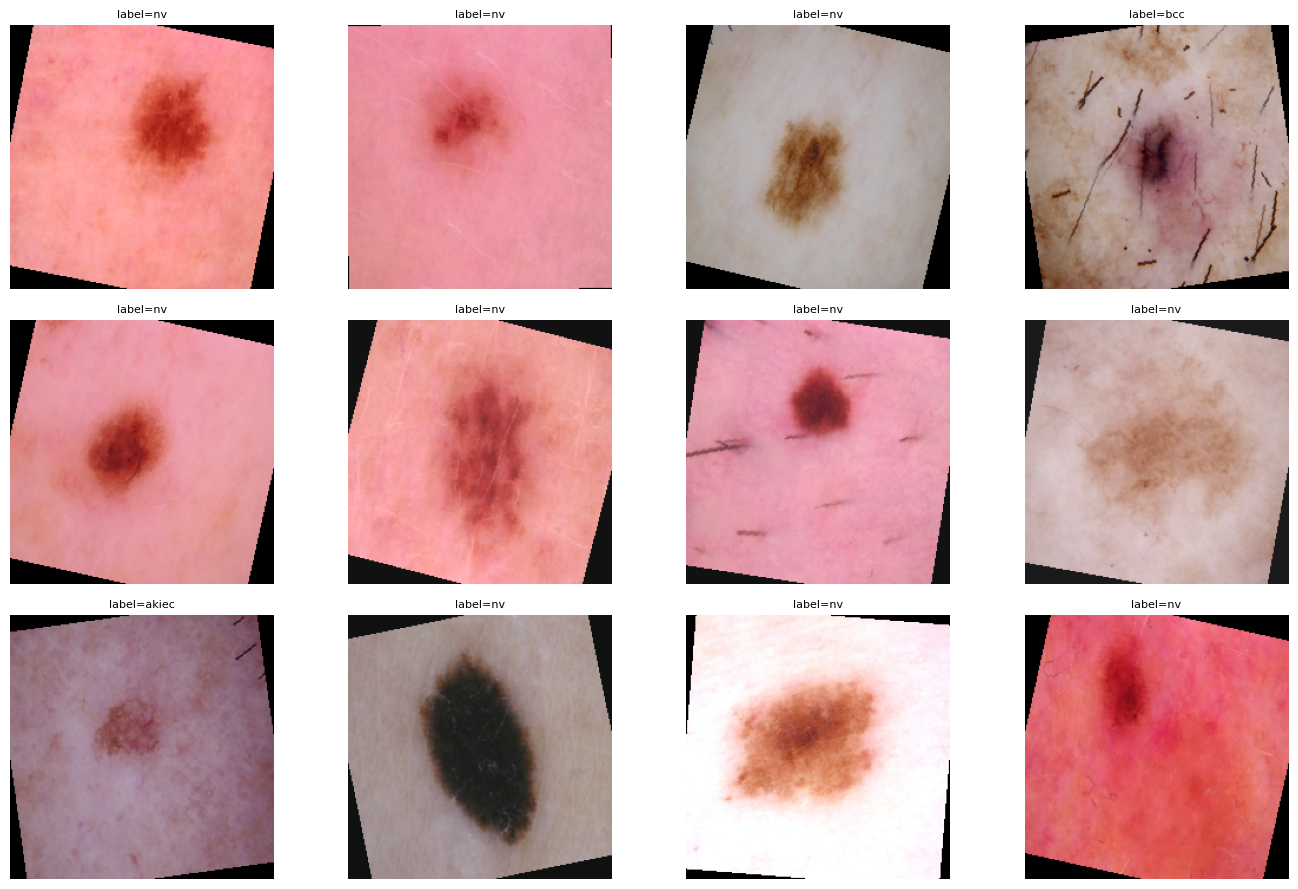

In [11]:
batch_imgs, batch_lbls = next(iter(train_loader))

aug_imgs   = [denormalize(batch_imgs[i]) for i in range(12)]
aug_titles = [f'label={HAM_LABELS[batch_lbls[i].item()]}' for i in range(12)]

show_image_grid(
    aug_imgs,
    titles=aug_titles,
    cols=4,
    figsize=(14, 9),
    save_path=RES_DIR / 'label_của_mẫu_Ham1000.png'
)

## 6. Xây dựng ResNet18

In [12]:
# ─── Model Source (Stage 1 – HAM10000 pretraining) ─────────────────────────
# Mục tiêu: Khởi tạo ResNet18 pretrained trên ImageNet,
#   freeze toàn bộ backbone, chỉ mở classification head mới.
#   Checkpoint tốt nhất sẽ được lưu lại để dùng làm điểm khởi đầu
#   cho transfer learning sang Derm7pt ở PH-05.

def build_source_model_from_imagenet():
    """
    Tạo mô hình ResNet18 (model_source) dùng cho giai đoạn pretraining trên HAM10000.

    Chiến lược:
    - Khởi tạo từ trọng số ImageNet pretrained.
    - Freeze toàn bộ backbone → chỉ train classification head mới (7 lớp HAM10000).
    - Từ epoch 6 trở đi backbone sẽ được unfreeze để fine-tune toàn bộ mạng.

    Checkpoint tốt nhất theo val_acc sẽ được load lại ở PH-05
    để transfer learning (fine-tune) sang tập Derm7pt.
    """
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Freeze backbone — chỉ train head mới
    for param in model.parameters():
        param.requires_grad = False

    # Thay classification head: 512 → NUM_CLASSES (7 lớp HAM10000)
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, NUM_CLASSES),
    )
    return model


model = build_source_model_from_imagenet().to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=compute_class_weights(train_ds).to(DEVICE))
optimizer = torch.optim.Adam(model.fc.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

print(model.fc)


Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=7, bias=True)
)


## 7. Hàm train và validate

In [13]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


def validate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)

## 8. Train ResNet18 và lưu best model

In [14]:
log_path = LOG_DIR / 'resnet18_log.csv'

with open(log_path, 'w', newline='') as f:
    csv.writer(f).writerow(['epoch', 'train_loss', 'val_loss', 'val_acc', 'lr'])

best_val_acc = 0.0
unfreeze_done = False

for epoch in range(1, NUM_EPOCHS + 1):

    if epoch == 6 and not unfreeze_done:
        print('\n[Unfreeze] Mở backbone để fine-tune toàn bộ...')
        for p in model.parameters():
            p.requires_grad = True

        optimizer = torch.optim.Adam([
            {'params': model.fc.parameters(), 'lr': LR},
            {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 'lr': LR * 0.1},
        ], weight_decay=WEIGHT_DECAY)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
        unfreeze_done = True

    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model, val_loader, criterion)
    scheduler.step(val_loss)

    print(
        f'Epoch [{epoch:02d}/{NUM_EPOCHS}] ' +
        f'train_loss={train_loss:.4f} ' +
        f'val_loss={val_loss:.4f} ' +
        f'val_acc={val_acc:.4f} ' +
        f'({time.time() - t0:.1f}s)'
    )

    with open(log_path, 'a', newline='') as f:
        csv.writer(f).writerow([
            epoch,
            f'{train_loss:.6f}',
            f'{val_loss:.6f}',
            f'{val_acc:.6f}',
            f'{optimizer.param_groups[0]["lr"]:.2e}'
        ])

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        # Lưu best checkpoint của model_source (HAM10000).
        # File này sẽ được load lại ở PH-05 để làm điểm khởi đầu
        # cho transfer learning (fine-tune) sang tập Derm7pt.
        torch.save(
            {
                'epoch': epoch,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_loss': val_loss,
            },
            CKPT_DIR / 'resnet18_best.pth'
        )
        print(f'✅ Saved best val_acc = {val_acc:.4f}')

print(f'\nDone. Best val_acc = {best_val_acc:.4f}')

Epoch [01/10] train_loss=2.0037 val_loss=1.7937 val_acc=0.5709 (254.0s)
✅ Saved best val_acc = 0.5709
Epoch [02/10] train_loss=1.8072 val_loss=1.6571 val_acc=0.5935 (278.5s)
✅ Saved best val_acc = 0.5935
Epoch [03/10] train_loss=1.6941 val_loss=1.5539 val_acc=0.5828 (280.7s)
Epoch [04/10] train_loss=1.6247 val_loss=1.4830 val_acc=0.5689 (279.8s)
Epoch [05/10] train_loss=1.5863 val_loss=1.4485 val_acc=0.5795 (278.6s)

[Unfreeze] Mở backbone để fine-tune toàn bộ...
Epoch [06/10] train_loss=1.3328 val_loss=1.0522 val_acc=0.6414 (534.4s)
✅ Saved best val_acc = 0.6414
Epoch [07/10] train_loss=1.0227 val_loss=0.8895 val_acc=0.6893 (560.6s)
✅ Saved best val_acc = 0.6893
Epoch [08/10] train_loss=0.9210 val_loss=0.7940 val_acc=0.7139 (560.9s)
✅ Saved best val_acc = 0.7139
Epoch [09/10] train_loss=0.8401 val_loss=0.7521 val_acc=0.6880 (563.7s)
Epoch [10/10] train_loss=0.7528 val_loss=0.7208 val_acc=0.7265 (555.6s)
✅ Saved best val_acc = 0.7265

Done. Best val_acc = 0.7265


## 9. Đọc CSV log

In [15]:
df_log = pd.read_csv(log_path)
df_log

,epoch,train_loss,val_loss,val_acc,lr
0,1,2.003728,1.793669,0.570858,0.0001
1,2,1.807151,1.657103,0.593480,0.0001
2,3,1.694075,1.553912,0.582834,0.0001
3,4,1.624712,1.483040,0.568862,0.0001
4,5,1.586280,1.448511,0.579508,0.0001
5,6,1.332845,1.052171,0.641384,0.0001
6,7,1.022712,0.889524,0.689288,0.0001
7,8,0.920980,0.794016,0.713906,0.0001
8,9,0.840112,0.752106,0.687957,0.0001
9,10,0.752847,0.720818,0.726547,0.0001


## 10. Vẽ biểu đồ bằng matplotlib

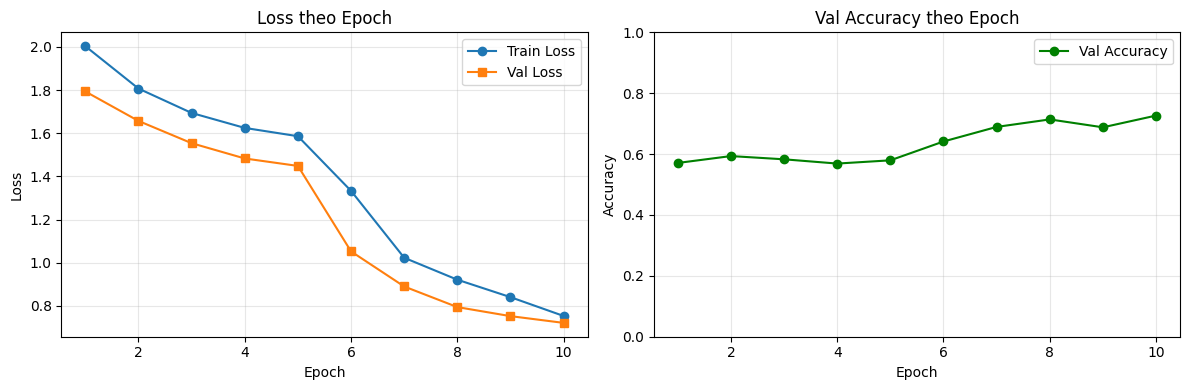

Đã lưu biểu đồ tại: c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT\results\ph04_resnet_outputs\loss_và_val_resnet18.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df_log['epoch'], df_log['train_loss'], marker='o', label='Train Loss')
axes[0].plot(df_log['epoch'], df_log['val_loss'], marker='s', label='Val Loss')
axes[0].set_title('Loss theo Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_log['epoch'], df_log['val_acc'], marker='o', color='green', label='Val Accuracy')
axes[1].set_title('Val Accuracy theo Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RES_DIR / 'loss và val resnet18.png', dpi=150)
plt.show()

print(f'Đã lưu biểu đồ tại: {RES_DIR / "loss_và_val_resnet18.png"}')

## 11. Load best checkpoint để visualize (mới)

In [17]:
ckpt = torch.load(CKPT_DIR / 'resnet18_best.pth', map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model = model.to(DEVICE)
model.eval()
print(f"Loaded best checkpoint — epoch={ckpt['epoch']}, val_acc={ckpt['val_acc']:.4f}")

Loaded best checkpoint — epoch=10, val_acc=0.7265


## 12. Sample predictions đúng / sai trên Validation set (mới)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_28016\1661917990.py:19: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_28016\1661917990.py:19: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_28016\1661917990.py:21: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=200, bbox_inches='tight')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_28016\1661917990.py:21: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=200, bbox_inches='tight')


Saved: c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT\results\ph04_resnet_outputs\resnet_ham10000_val_predictions.png


C:\Users\ADMIN\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ADMIN\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


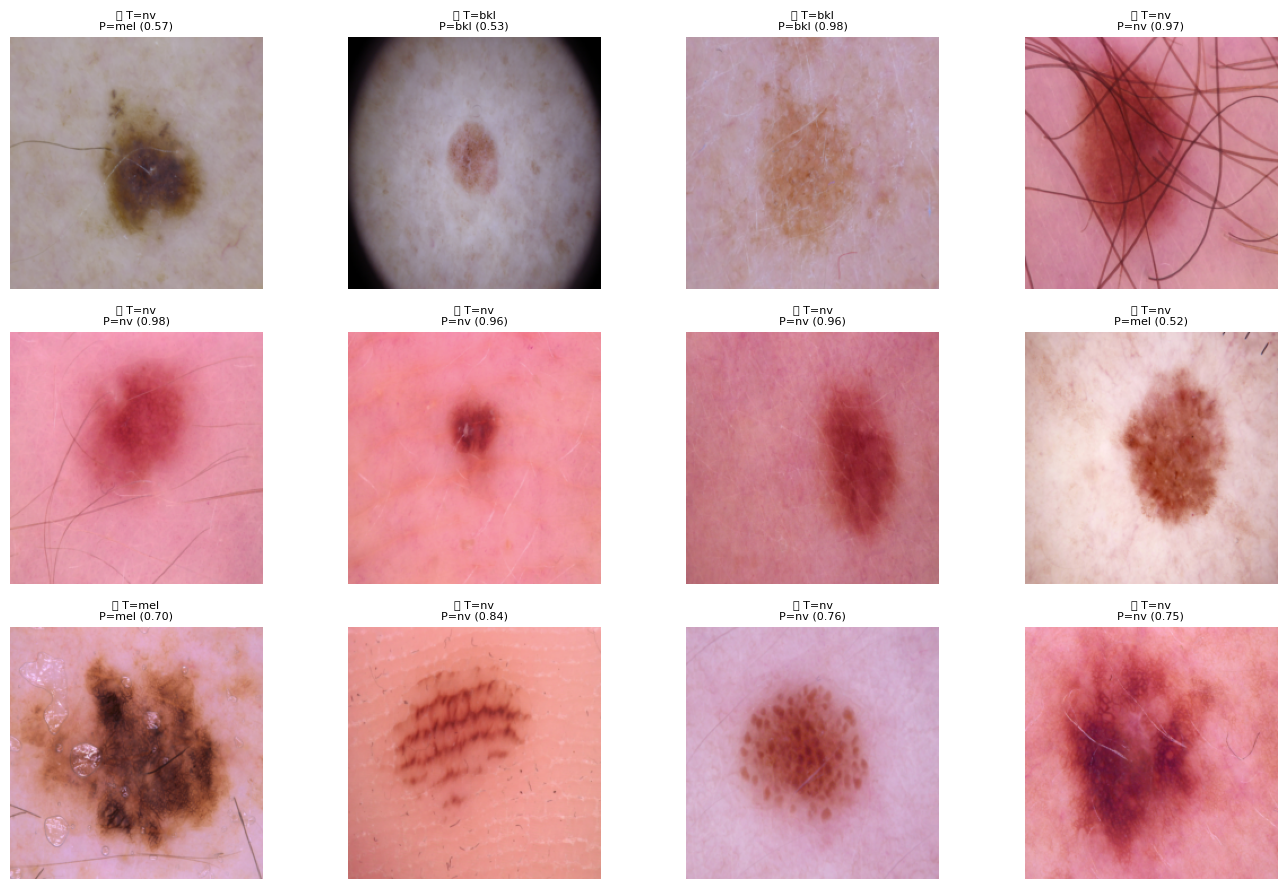

In [18]:
all_imgs, y_true, y_pred, y_probs = collect_predictions(model, val_loader, DEVICE)

random.seed(42)
idxs = list(range(len(all_imgs)))
random.shuffle(idxs)
sample_idxs = idxs[:12]

vis_imgs, vis_titles = [], []
for i in sample_idxs:
    mark = '✅' if y_true[i] == y_pred[i] else '❌'
    vis_imgs.append(denormalize(all_imgs[i]))
    vis_titles.append(
        f"{mark} T={HAM_LABELS[y_true[i]]}\nP={HAM_LABELS[y_pred[i]]} ({y_probs[i][y_pred[i]]:.2f})"
    )

show_image_grid(
    vis_imgs,
    titles=vis_titles,
    cols=4,
    figsize=(14, 9),
    save_path=RES_DIR / 'resnet_ham10000_val_predictions.png'
)

## 13. Confusion Matrix trên Validation set (mới)

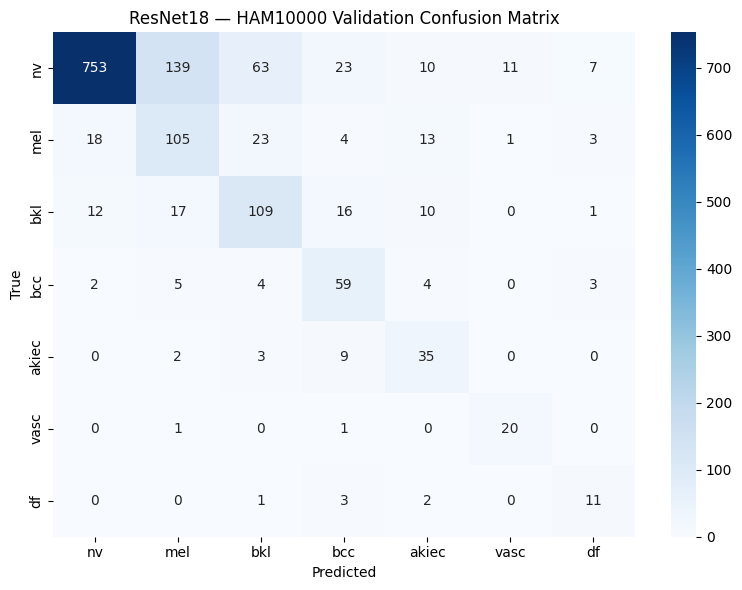

In [19]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=HAM_LABELS, yticklabels=HAM_LABELS)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('ResNet18 — HAM10000 Validation Confusion Matrix')
plt.tight_layout()
plt.show()

## 14. Classification Report (mới)

In [20]:
report = classification_report(y_true, y_pred, target_names=HAM_LABELS, digits=4)
print(report)

with open(RES_DIR / 'resnet_ham10000_classification_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)
print('Saved classification report.')

              precision    recall  f1-score   support

          nv     0.9592    0.7485    0.8409      1006
         mel     0.3903    0.6287    0.4817       167
         bkl     0.5369    0.6606    0.5924       165
         bcc     0.5130    0.7662    0.6146        77
       akiec     0.4730    0.7143    0.5691        49
        vasc     0.6250    0.9091    0.7407        22
          df     0.4400    0.6471    0.5238        17

    accuracy                         0.7265      1503
   macro avg     0.5625    0.7249    0.6233      1503
weighted avg     0.8002    0.7265    0.7482      1503

Saved classification report.
